# IMC Prosperity — Round 0 Price Data Visualization

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as sp_stats

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.formatter.useoffset": False,
})

# Load both days
DATA_DIR = "TUTORIAL_ROUND_1"
dfs = []
for day in [-2, -1]:
    df = pd.read_csv(f"{DATA_DIR}/prices_round_0_day_{day}.csv", sep=";")
    dfs.append(df)
prices = pd.concat(dfs, ignore_index=True)

# Derived columns
prices["spread"] = prices["ask_price_1"] - prices["bid_price_1"]
for side in ["bid", "ask"]:
    prices[f"{side}_vol_total"] = (
        prices[[f"{side}_volume_1", f"{side}_volume_2", f"{side}_volume_3"]]
        .fillna(0).sum(axis=1)
    )
prices["imbalance"] = (
    (prices["bid_vol_total"] - prices["ask_vol_total"]) /
    (prices["bid_vol_total"] + prices["ask_vol_total"]).replace(0, np.nan)
)

products = sorted(prices["product"].unique())
COLORS = plt.rcParams["axes.prop_cycle"].by_key()["color"]
DAY_COLORS = {-2: COLORS[0], -1: COLORS[1]}

print("Products:", products)
print("Days:    ", sorted(prices["day"].unique()))
print(f"Shape:    {prices.shape}")
prices.head()

Products: ['EMERALDS', 'TOMATOES']
Days:     [np.int64(-2), np.int64(-1)]
Shape:    (40000, 21)


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,...,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,spread,bid_vol_total,ask_vol_total,imbalance
0,-2,0,EMERALDS,9992,11,9990,25,NaN,NaN,10008,...,10010,25,NaN,NaN,10000.0,0.0,16,36.0,36.0,0.000000
1,-2,0,TOMATOES,4993,7,4992,17,NaN,NaN,5007,...,5008,17,NaN,NaN,5000.0,0.0,14,24.0,24.0,0.000000
2,-2,100,TOMATOES,4998,5,4993,7,4992.0,16.0,5007,...,5008,16,NaN,NaN,5002.5,0.0,9,28.0,23.0,0.098039
3,-2,100,EMERALDS,9992,15,9990,20,NaN,NaN,10008,...,10010,20,NaN,NaN,10000.0,0.0,16,35.0,35.0,0.000000
4,-2,200,TOMATOES,4994,6,4993,20,NaN,NaN,5008,...,5009,20,NaN,NaN,5001.0,0.0,14,26.0,26.0,0.000000


## 1 — Mid-Price Over Time

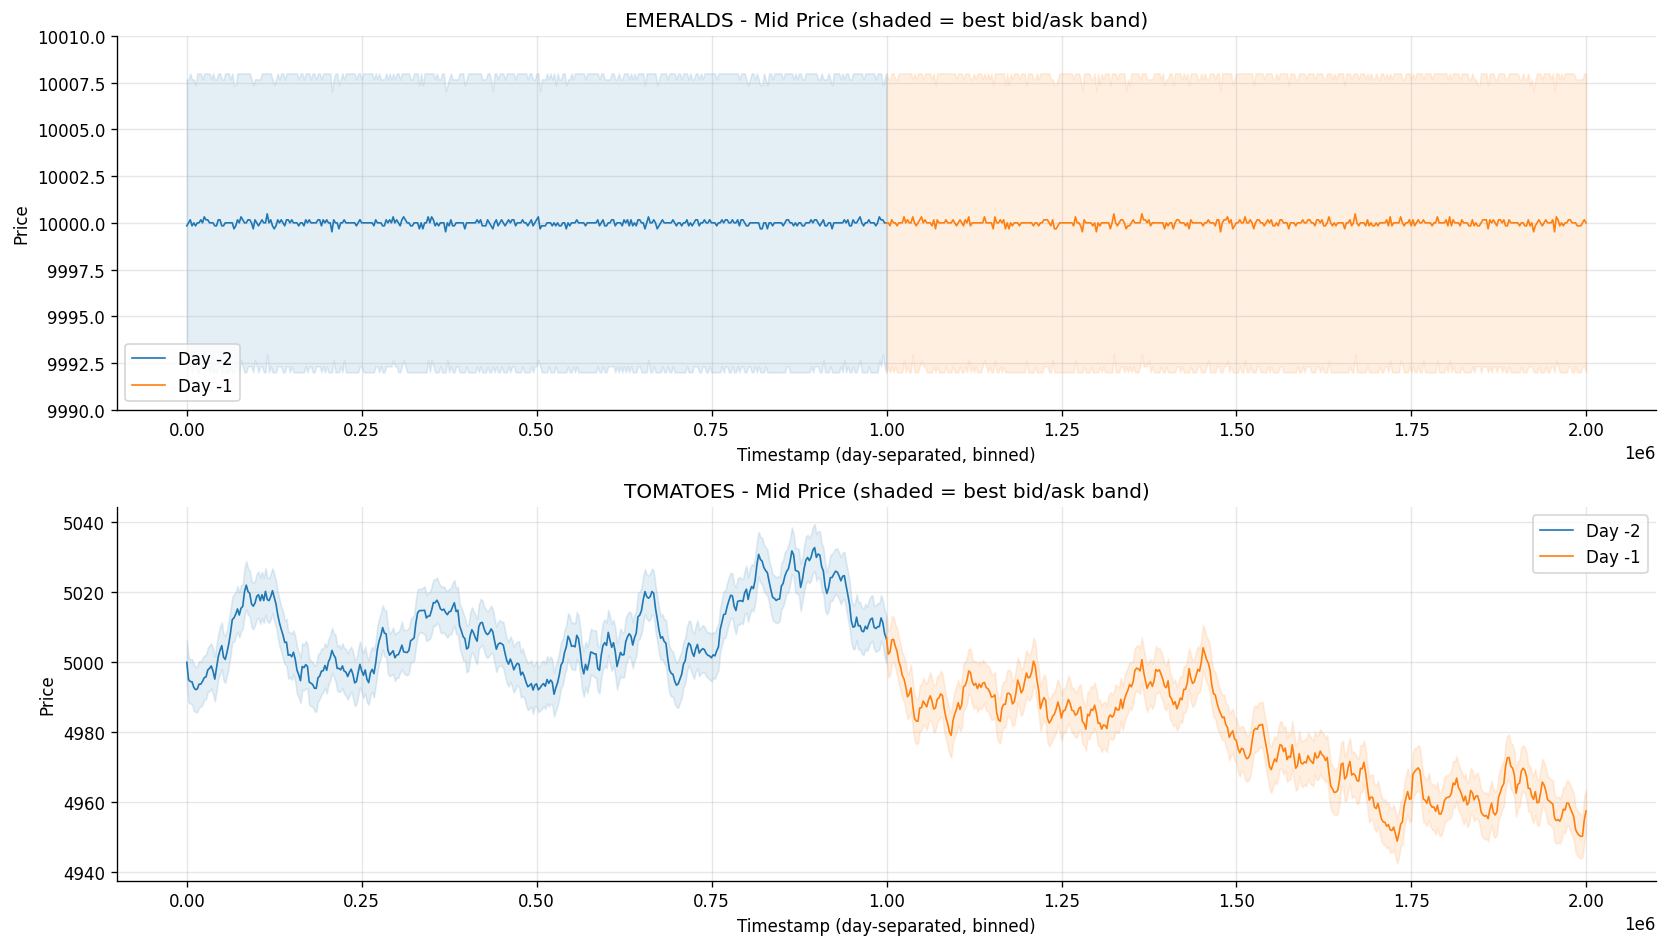

In [2]:
n = len(products)
fig, axes = plt.subplots(n, 1, figsize=(14, 4 * n), sharex=False)
if n == 1:
    axes = [axes]

# Avoid overlaying different days on the same timestamp range.
# This prevents barcode-like artifacts when day-level prices differ.
days = sorted(prices["day"].unique())
ts_min = prices["timestamp"].min()
ts_span = prices["timestamp"].max() - ts_min + 1
day_offset = {day: i * ts_span for i, day in enumerate(days)}

# Use adaptive time bins so coarse-grid products (like EMERALDS)
# are readable instead of appearing as dense vertical stripes.
BIN_SIZE = max(100, int(ts_span / 400))

for ax, product in zip(axes, products):
    for day, grp in prices[prices["product"] == product].groupby("day"):
        grp = grp.sort_values("timestamp").drop_duplicates("timestamp", keep="last")

        binned = (
            grp.assign(ts_bin=(grp["timestamp"] // BIN_SIZE) * BIN_SIZE)
               .groupby("ts_bin", as_index=False)
               .agg(
                   mid_price=("mid_price", "mean"),
                   bid_price_1=("bid_price_1", "mean"),
                   ask_price_1=("ask_price_1", "mean"),
               )
        )

        x = binned["ts_bin"] - ts_min + day_offset[day]
        ax.plot(x, binned["mid_price"],
                color=DAY_COLORS[day], lw=1, label=f"Day {day}")
        ax.fill_between(x, binned["bid_price_1"], binned["ask_price_1"],
                        color=DAY_COLORS[day], alpha=0.12)

    if product == "EMERALDS":
        psub = prices[prices["product"] == product]
        ax.set_ylim(psub["bid_price_1"].min() - 2, psub["ask_price_1"].max() + 2)

    ax.set_title(f"{product} - Mid Price (shaded = best bid/ask band)", fontsize=12)
    ax.set_ylabel("Price")
    ax.set_xlabel("Timestamp (day-separated, binned)")
    ax.legend()

plt.tight_layout()
plt.show()

## 2 — Bid-Ask Spread Over Time

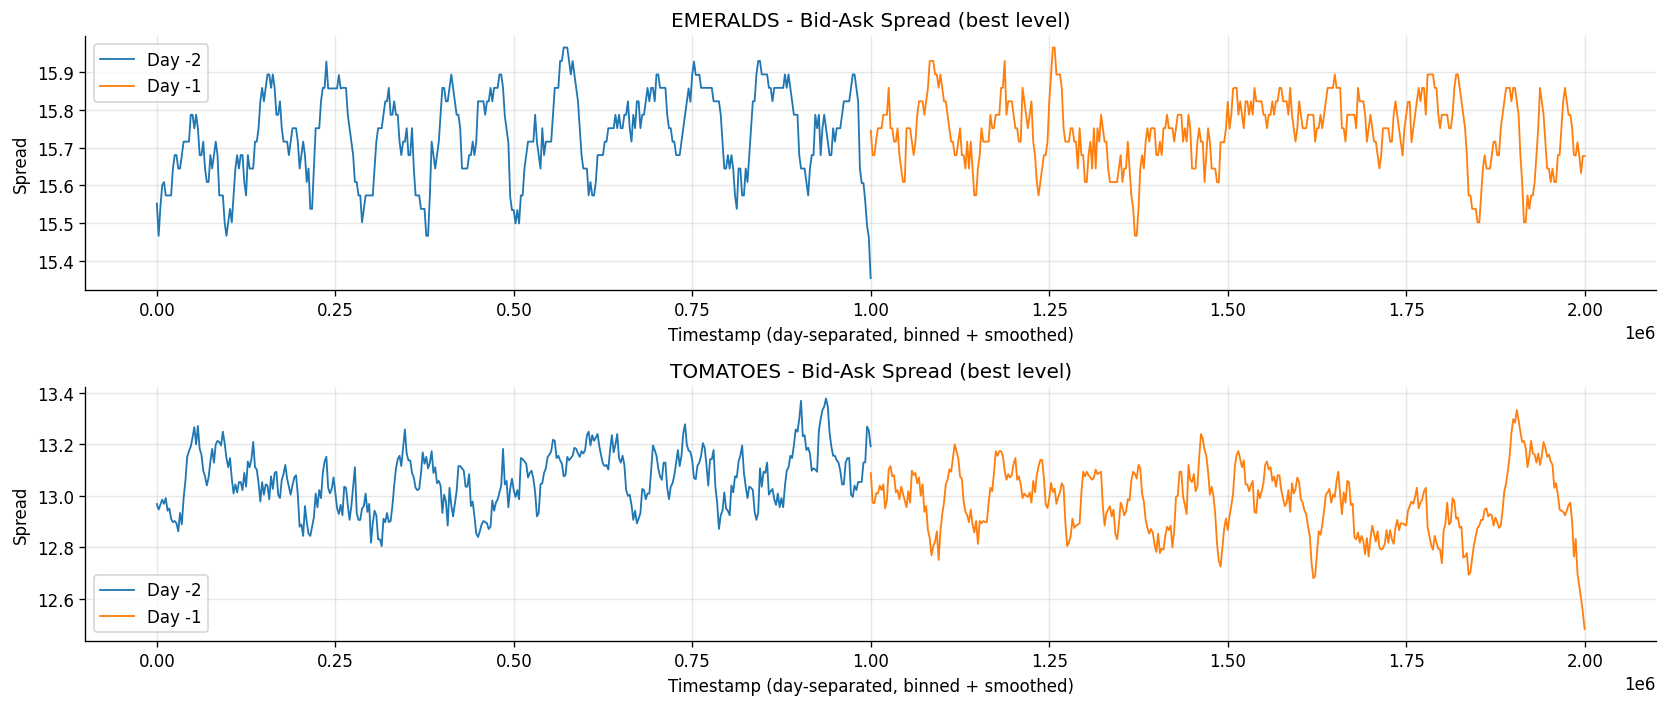

In [3]:
fig, axes = plt.subplots(n, 1, figsize=(14, 3 * n), sharex=False)
if n == 1:
    axes = [axes]

# Separate days on the x-axis and smooth with adaptive time bins
# so spread plots are readable for coarse-grid products.
days = sorted(prices["day"].unique())
ts_min = prices["timestamp"].min()
ts_span = prices["timestamp"].max() - ts_min + 1
day_offset = {day: i * ts_span for i, day in enumerate(days)}
BIN_SIZE = max(100, int(ts_span / 400))
SMOOTH_WINDOW = 9

for ax, product in zip(axes, products):
    for day, grp in prices[prices["product"] == product].groupby("day"):
        grp = grp.sort_values("timestamp").drop_duplicates("timestamp", keep="last")

        binned = (
            grp.assign(ts_bin=(grp["timestamp"] // BIN_SIZE) * BIN_SIZE)
               .groupby("ts_bin", as_index=False)
               .agg(spread=("spread", "mean"))
        )
        binned["spread_smooth"] = (
            binned["spread"].rolling(SMOOTH_WINDOW, center=True, min_periods=1).mean()
        )

        x = binned["ts_bin"] - ts_min + day_offset[day]
        ax.plot(x, binned["spread_smooth"],
                color=DAY_COLORS[day], lw=1.1, label=f"Day {day}")

    ax.set_title(f"{product} - Bid-Ask Spread (best level)", fontsize=12)
    ax.set_ylabel("Spread")
    ax.set_xlabel("Timestamp (day-separated, binned + smoothed)")
    ax.legend()

plt.tight_layout()
plt.show()

## 3 — Rolling Volatility (std of mid-price returns)

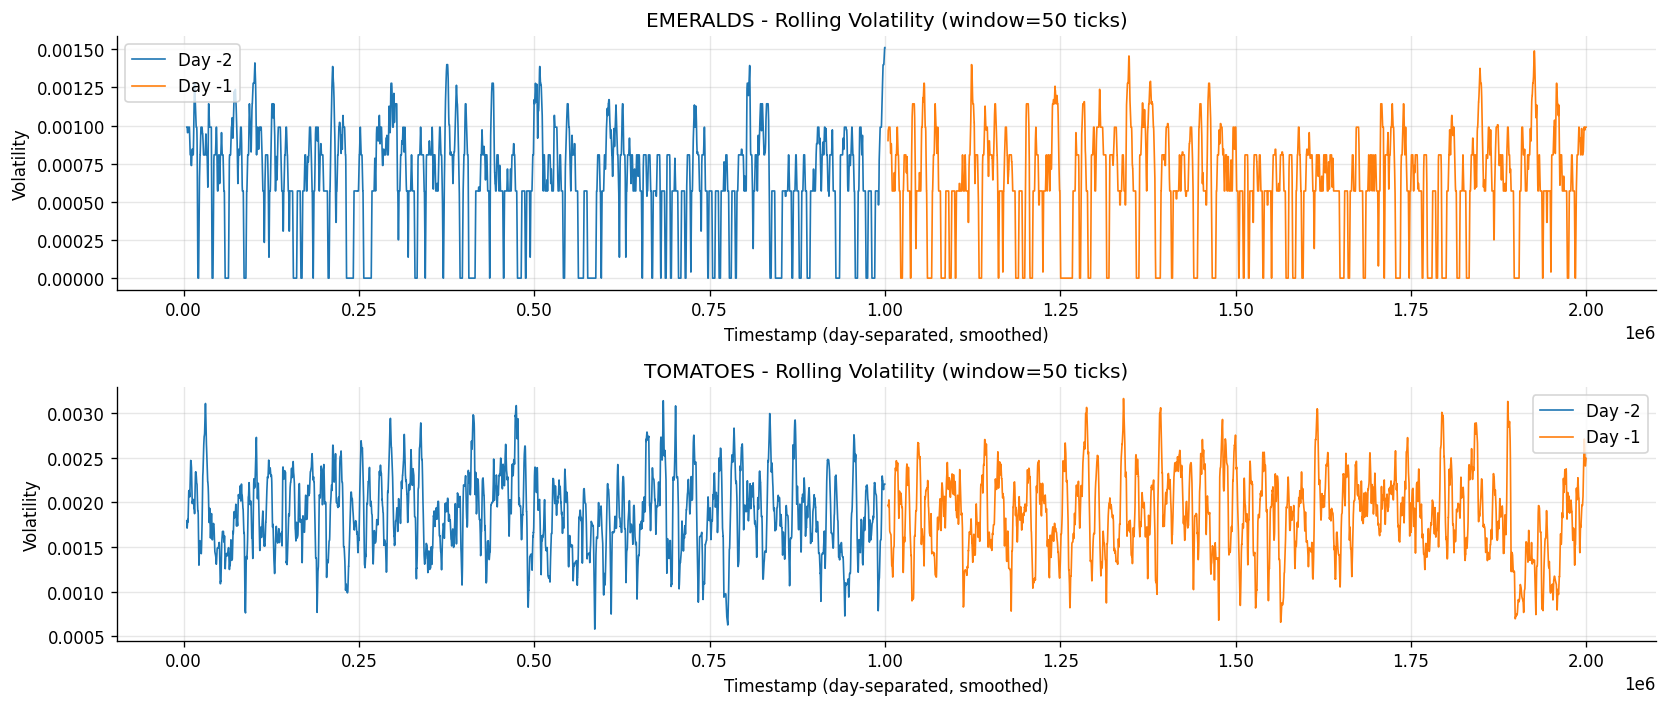

In [4]:
WINDOW = 50  # ticks
VOL_SMOOTH_WINDOW = 10

fig, axes = plt.subplots(n, 1, figsize=(14, 3 * n), sharex=False)
if n == 1:
    axes = [axes]

# Separate days on the x-axis so volatility lines do not overlap.
days = sorted(prices["day"].unique())
ts_min = prices["timestamp"].min()
ts_span = prices["timestamp"].max() - ts_min + 1
day_offset = {day: i * ts_span for i, day in enumerate(days)}

for ax, product in zip(axes, products):
    for day, grp in prices[prices["product"] == product].groupby("day"):
        grp = grp.sort_values("timestamp").drop_duplicates("timestamp", keep="last")
        returns = grp["mid_price"].pct_change()
        rolling_vol = returns.rolling(WINDOW).std() * np.sqrt(WINDOW)
        rolling_vol_smooth = rolling_vol.rolling(VOL_SMOOTH_WINDOW, center=True, min_periods=1).mean()
        x = grp["timestamp"] - ts_min + day_offset[day]
        ax.plot(x.values, rolling_vol_smooth.values,
                color=DAY_COLORS[day], lw=1.0, label=f"Day {day}")

    ax.set_title(f"{product} - Rolling Volatility (window={WINDOW} ticks)", fontsize=12)
    ax.set_ylabel("Volatility")
    ax.set_xlabel("Timestamp (day-separated, smoothed)")
    ax.legend()

plt.tight_layout()
plt.show()

## 4 — Order Book Depth (stacked bid/ask volumes)

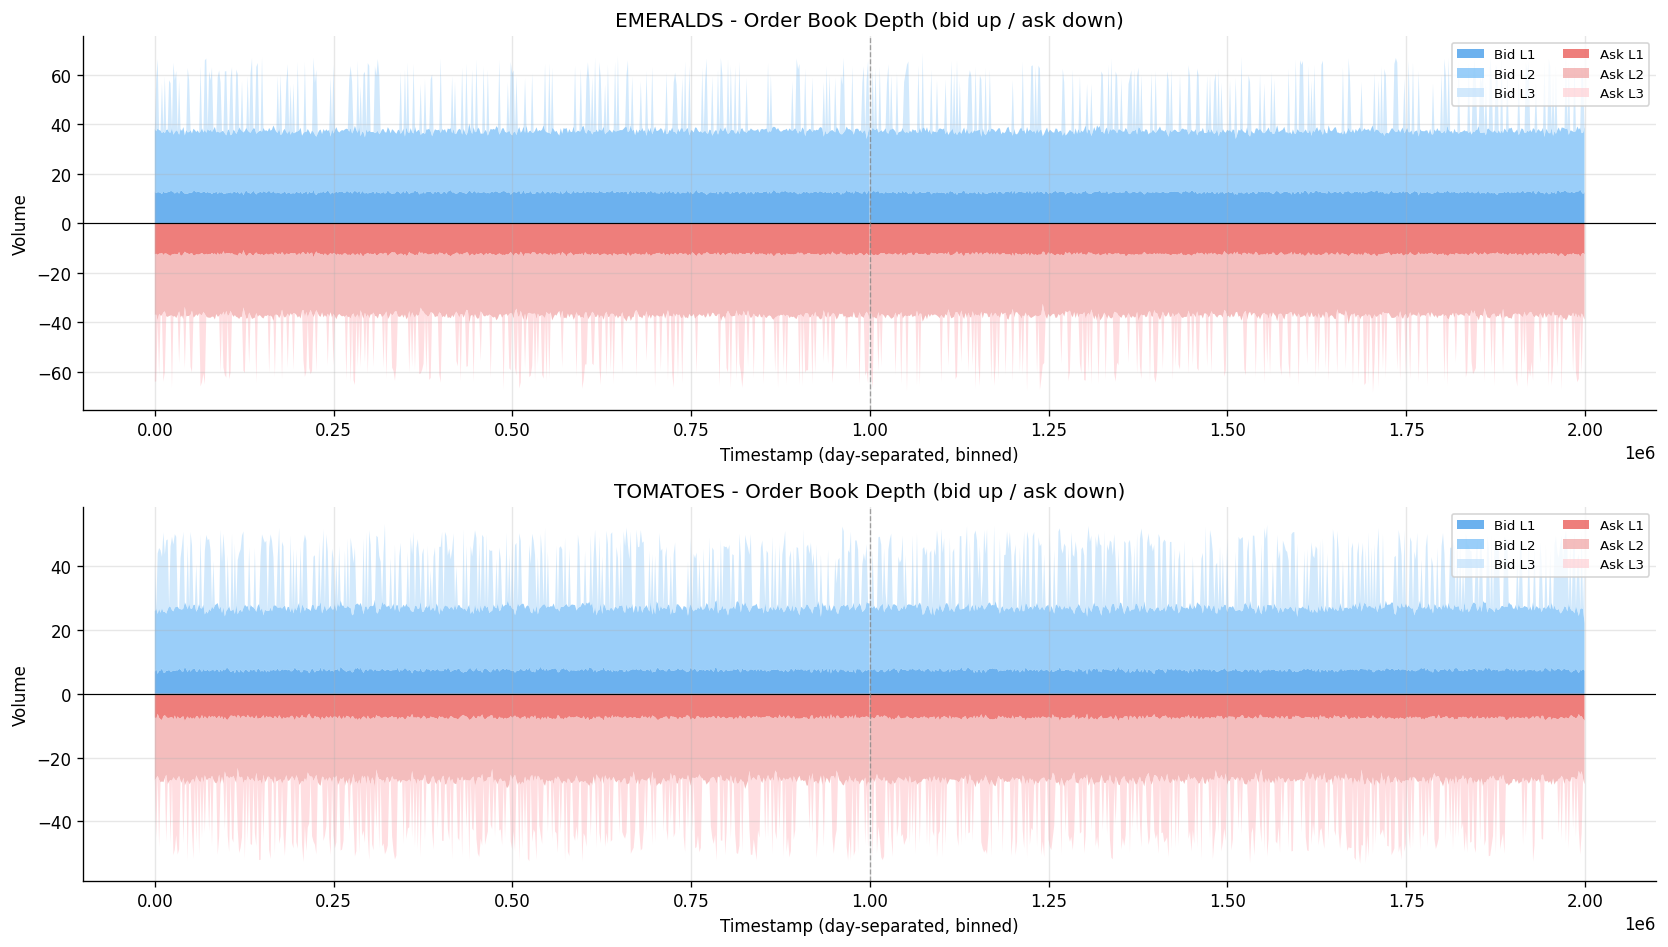

In [5]:
fig, axes = plt.subplots(n, 1, figsize=(14, 4 * n), sharex=False)
if n == 1:
    axes = [axes]

# Separate days and bin timestamps to reduce visual clutter.
days = sorted(prices["day"].unique())
ts_min = prices["timestamp"].min()
ts_span = prices["timestamp"].max() - ts_min + 1
day_offset = {day: i * ts_span for i, day in enumerate(days)}
BIN_SIZE = max(100, int(ts_span / 500))

for ax, product in zip(axes, products):
    for day in days:
        grp = prices[(prices["product"] == product) & (prices["day"] == day)]
        grp = grp.sort_values("timestamp").drop_duplicates("timestamp", keep="last")

        binned = (
            grp.assign(ts_bin=(grp["timestamp"] // BIN_SIZE) * BIN_SIZE)
               .groupby("ts_bin", as_index=False)
               .agg(
                   b1=("bid_volume_1", "mean"),
                   b2=("bid_volume_2", "mean"),
                   b3=("bid_volume_3", "mean"),
                   a1=("ask_volume_1", "mean"),
                   a2=("ask_volume_2", "mean"),
                   a3=("ask_volume_3", "mean"),
               )
               .fillna(0)
        )

        x = binned["ts_bin"] - ts_min + day_offset[day]
        bid_labels = ["Bid L1", "Bid L2", "Bid L3"] if day == days[0] else [None, None, None]
        ask_labels = ["Ask L1", "Ask L2", "Ask L3"] if day == days[0] else [None, None, None]

        ax.stackplot(x, binned["b1"], binned["b2"], binned["b3"],
                     labels=bid_labels,
                     colors=["#1E88E5", "#64B5F6", "#BBDEFB"], alpha=0.65)
        ax.stackplot(x, -binned["a1"], -binned["a2"], -binned["a3"],
                     labels=ask_labels,
                     colors=["#E53935", "#EF9A9A", "#FFCDD2"], alpha=0.65)

    ax.axhline(0, color="black", lw=0.7)
    ax.axvline(ts_span, color="gray", lw=0.8, linestyle="--", alpha=0.7)
    ax.set_title(f"{product} - Order Book Depth (bid up / ask down)", fontsize=12)
    ax.set_ylabel("Volume")
    ax.set_xlabel("Timestamp (day-separated, binned)")
    ax.legend(loc="upper right", ncol=2, fontsize=8, frameon=True)

plt.tight_layout()
plt.show()

## 5 — Mid-Price Return Distribution

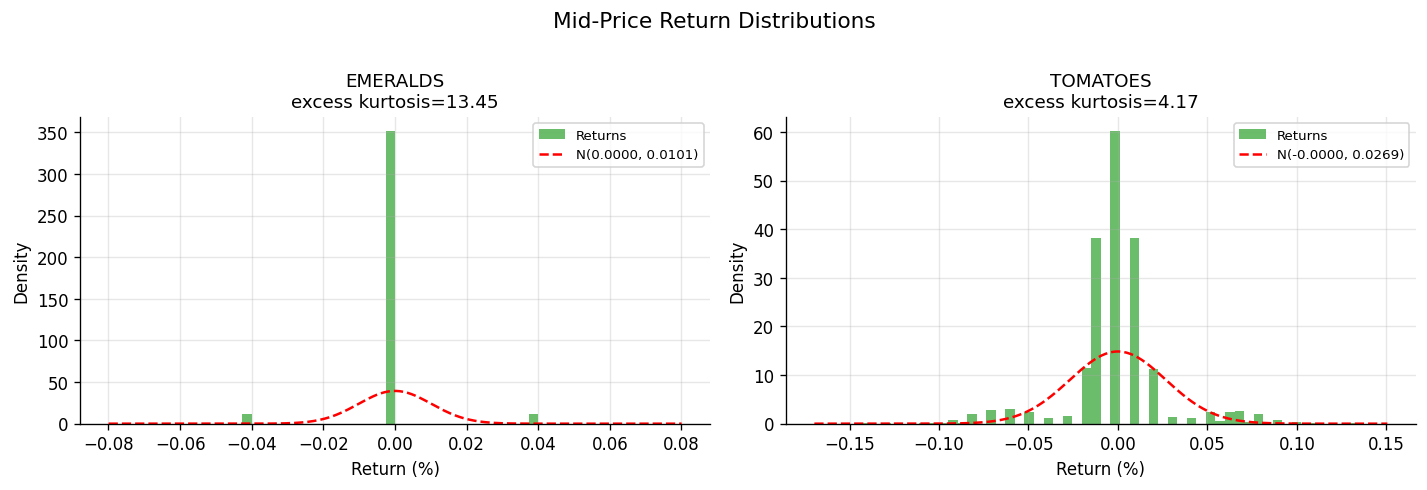

In [6]:
fig, axes = plt.subplots(1, n, figsize=(6 * n, 4))
if n == 1:
    axes = [axes]

for ax, product in zip(axes, products):
    sub = prices[prices["product"] == product].sort_values(["day", "timestamp"])
    rets = sub["mid_price"].pct_change().dropna() * 100

    ax.hist(rets, bins=60, density=True, color=COLORS[2], alpha=0.7, label="Returns")
    mu, sigma = rets.mean(), rets.std()
    x = np.linspace(rets.min(), rets.max(), 300)
    ax.plot(x, sp_stats.norm.pdf(x, mu, sigma), "r--", lw=1.5,
            label=f"N({mu:.4f}, {sigma:.4f})")
    kurt = sp_stats.kurtosis(rets)
    ax.set_title(f"{product}\nexcess kurtosis={kurt:.2f}", fontsize=11)
    ax.set_xlabel("Return (%)")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

plt.suptitle("Mid-Price Return Distributions", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 6 — Spread Distribution

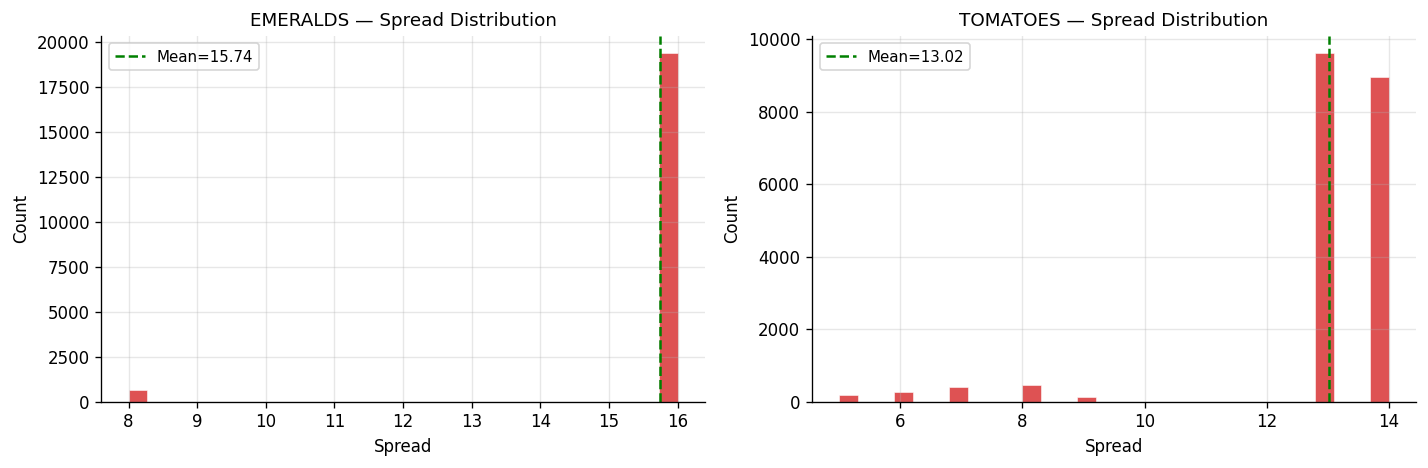

In [7]:
fig, axes = plt.subplots(1, n, figsize=(6 * n, 4))
if n == 1:
    axes = [axes]

for ax, product in zip(axes, products):
    sub = prices[prices["product"] == product]
    spread_vals = sub["spread"].dropna()
    ax.hist(spread_vals, bins=30, color=COLORS[3], alpha=0.8, edgecolor="white", lw=0.4)
    ax.axvline(spread_vals.mean(), color="green", lw=1.5, linestyle="--",
               label=f"Mean={spread_vals.mean():.2f}")
    ax.set_title(f"{product} — Spread Distribution", fontsize=11)
    ax.set_xlabel("Spread")
    ax.set_ylabel("Count")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 7 — Order Book Imbalance Over Time

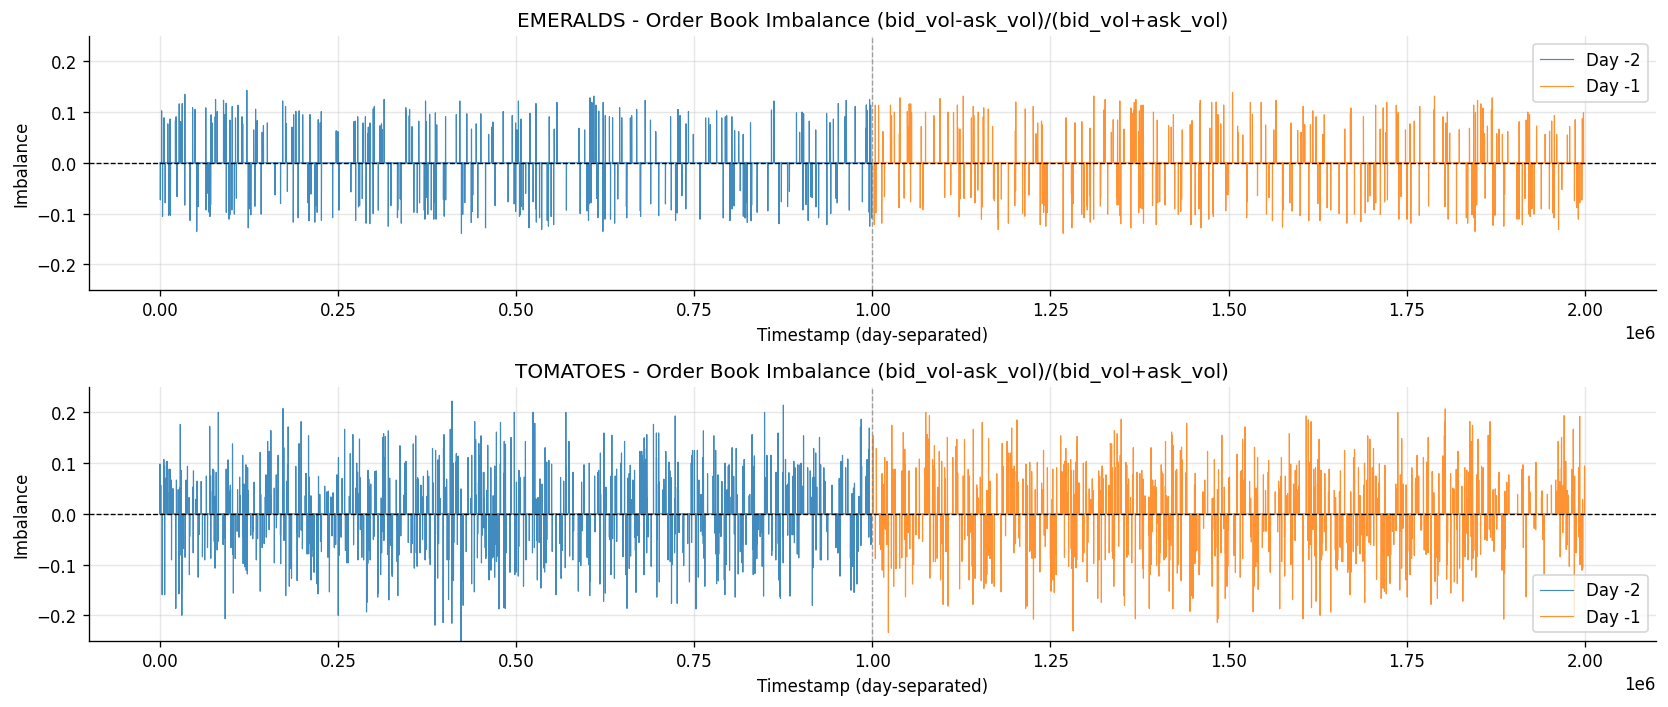

In [8]:
fig, axes = plt.subplots(n, 1, figsize=(14, 3 * n), sharex=False)
if n == 1:
    axes = [axes]

# Separate days on the x-axis so day -2 and -1 do not overlap.
days = sorted(prices["day"].unique())
ts_min = prices["timestamp"].min()
ts_span = prices["timestamp"].max() - ts_min + 1
day_offset = {day: i * ts_span for i, day in enumerate(days)}

for ax, product in zip(axes, products):
    for day, grp in prices[prices["product"] == product].groupby("day"):
        grp = grp.sort_values("timestamp").drop_duplicates("timestamp", keep="last")
        x = grp["timestamp"] - ts_min + day_offset[day]
        ax.plot(x.values, grp["imbalance"].values,
                color=DAY_COLORS[day], lw=0.7, alpha=0.85, label=f"Day {day}")
    ax.axhline(0, color="black", lw=0.8, linestyle="--")
    ax.axvline(ts_span, color="gray", lw=0.8, linestyle="--", alpha=0.7)
    ax.set_ylim(-0.25, 0.25)
    ax.set_title(f"{product} - Order Book Imbalance (bid_vol-ask_vol)/(bid_vol+ask_vol)", fontsize=12)
    ax.set_ylabel("Imbalance")
    ax.set_xlabel("Timestamp (day-separated)")
    ax.legend()

plt.tight_layout()
plt.show()

## 8 — Summary Statistics

In [9]:
rows = []
for product in products:
    sub = prices[prices["product"] == product].sort_values(["day", "timestamp"])
    rets = sub["mid_price"].pct_change().dropna() * 100
    rows.append({
        "Product": product,
        "Mid Mean": sub["mid_price"].mean(),
        "Mid Std": sub["mid_price"].std(),
        "Mid Min": sub["mid_price"].min(),
        "Mid Max": sub["mid_price"].max(),
        "Return Mean (%)": rets.mean(),
        "Return Std (%)": rets.std(),
        "Kurtosis": sp_stats.kurtosis(rets),
        "Mean Spread": sub["spread"].mean(),
        "Mean Bid Vol": sub["bid_vol_total"].mean(),
        "Mean Ask Vol": sub["ask_vol_total"].mean(),
    })

summary = pd.DataFrame(rows).set_index("Product")
pd.set_option("display.float_format", "{:.4f}".format)
summary

,Mid Mean,Mid Std,Mid Min,Mid Max,Return Mean (%),Return Std (%),Kurtosis,Mean Spread,Mean Bid Vol,Mean Ask Vol
Product,,,,,,,,,,
EMERALDS,9999.9976,0.7233,9996.0000,10004.0000,0.0000,0.0101,13.4489,15.7384,37.6660,37.6735
TOMATOES,4992.7581,19.7471,4946.5000,5036.0000,-0.0000,0.0269,4.1682,13.0203,27.7494,27.7498
